In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt

plt.style.use("bmh")
plt.rcParams["axes.axisbelow"] = True
import numpy as np
import pandas
import pandas as pd
from pandas import DataFrame, Index, Series, Timedelta, Timestamp
import matplotlib.dates as mdates
rng = np.random.default_rng()
np.set_printoptions()

import torch
import torchinfo
from torch import Tensor, jit, tensor
from torch.utils.data import DataLoader
from copy import deepcopy

## Config

In [3]:
ID = (439, 15325)  # the Run_id / Experiment_id we want to plot.

# files:  2021-11-12T00:52:10 2021-11-12T00:51:55 2021-11-12T00:51:48
# "checkpoints/2021-11-15T12:05:00/LinODEnet-0"
# "checkpoints/LinODEnet/KIWI_RUNS/skew_allways/2021-11-15T16:05:41/LinODEnet-0"
# "adam/2021-11-15T20:38:52/LinODEnet-0"
PATH = "checkpoints/LinODEnet/KIWI_RUNS/"
NAME = "adam/2021-11-15T20:38:52/LinODEnet-0"
MODEL_FILE = PATH + NAME  # the model checkpoint
DEVICE = torch.device("cpu")
DTYPE = torch.float32
NAN = tensor(float("nan"), dtype=DTYPE, device=DEVICE)

tensor(nan)

In [4]:
def apply_along_axes(a: Tensor, b: Tensor, op, axes: tuple[int, ...]) -> Tensor:
    print(a.shape, axes)
    rank = len(a.shape)
    axes = tuple(ax%rank for ax in axes)
    source = tuple(range(rank))
    iperm = axes + tuple(ax for ax in range(rank) if ax not in axes)
    perm = tuple(np.argsort(iperm))
    print(source, perm, iperm)
    a = a.moveaxis(source, perm)
    # print(a.shape, b.shape)
    a = op(a, b)
    a = a.moveaxis(source, iperm)
    # print(a.shape)
    return a

In [5]:
data = torch.randn(7,8,9)
data[data>0] = NAN
axes = (-1, )
mask = ~torch.isnan(data)
count = mask.sum(dim=axes)
masked = torch.where(mask, data, tensor(0.0))
print(f"{torch.isnan(masked).any()=}")
mean = masked.sum(dim=axes)/count
residual = apply_along_axes(masked, mean, torch.sub, axes=axes)
stdv = (residual**2).sum(dim=axes)/torch.minimum(torch.tensor(1.0), count-1)

torch.isnan(masked).any()=tensor(False)
torch.Size([7, 8, 9]) (-1,)
(0, 1, 2) (1, 2, 0) (2, 0, 1)


tensor([[ 2.3374,  5.9491,  3.3175, 16.5081,  2.7934,  6.5425,  5.2953,  9.8276],
        [ 3.4496,  6.6955,  4.0170,  3.4806,  3.9036,  5.3674,  1.8189,  3.1786],
        [ 4.5127,  2.1332,  1.2919,  4.6173,  6.7924,  9.0607,  6.3706,  5.3403],
        [ 4.1410,  6.0073,  1.4291,  3.1608,  2.2604,  2.9232,     nan,  3.2000],
        [ 3.2907,  8.6318,  0.6197,  4.5487,  9.9085,  2.3192,  8.6642,  4.4752],
        [ 1.2695,     inf,  4.6979,  1.6962,  2.6942,  1.7712,  1.4099,  5.9382],
        [ 9.6482,  7.1557,  4.7485,  9.6735,  1.2928,  2.2943,     inf,  3.4797]])

In [6]:
from tsdm.tasks import KIWI_RUNS_TASK

task = KIWI_RUNS_TASK()
assert ID in task.splits[(0, "train")][0].index
TRAINLOADER = task.dataloaders[(0, "train")]
EVALLOADER = task.dataloaders[(0, "test")]

In [7]:
ts = task.timeseries
ts = ts.loc[ID].astype("float32")

variable,Flow_Air,StirringSpeed,Temperature,Acetate,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Glucose,OD600,Probe_Volume,pH,Fluo_GFP,InducerConcentration,Volume
measurement_time,,,,,,,,,,,,,,,
2020-12-09 09:10:09,0.0,0.0,36.389999,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:19,0.0,0.0,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,NaN,0.0,7.27,NaN,0.00,NaN
2020-12-09 09:10:24,0.0,100.0,NaN,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:25,0.0,100.0,36.130001,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:34,0.0,100.0,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,NaN,0.0,7.28,NaN,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-09 23:31:40,10.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,52.720001,NaN,NaN,3600.0,6.44,NaN,0.05,NaN
2020-12-09 23:31:42,0.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,NaN,NaN,NaN,3600.0,NaN,NaN,0.05,NaN
2020-12-09 23:31:51,0.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,52.950001,NaN,NaN,3600.0,6.44,NaN,0.05,NaN


## Load the Model

In [8]:
model = torch.jit.load(MODEL_FILE, torch.device("cpu"))
torchinfo.summary(model)

Layer (type:depth-idx)                             Param #
LinODEnet                                          --
├─ConcatEmbedding: 1-1                             113
├─iResNet: 1-2                                     --
│    └─Sequential: 2-1                             --
│    │    └─iResNetBlock: 3-1                      2,955
│    │    └─iResNetBlock: 3-2                      2,955
│    │    └─iResNetBlock: 3-3                      2,955
│    │    └─iResNetBlock: 3-4                      2,955
│    │    └─iResNetBlock: 3-5                      2,955
│    │    └─iResNetBlock: 3-6                      2,955
│    │    └─iResNetBlock: 3-7                      2,955
│    │    └─iResNetBlock: 3-8                      2,955
│    │    └─iResNetBlock: 3-9                      2,955
│    │    └─iResNetBlock: 3-10                     2,955
├─LinODECell: 1-3                                  16,384
├─iResNet: 1-4                                     --
│    └─Sequential: 2-2                    

## First Look: simply plot the first item from each dataloader

In [9]:
def prep_batch(batch: tuple[Tensor, Tensor]):
    """Get batch and create model inputs and targets"""
    T, X = batch
    targets = X[..., task.observation_horizon :, task.targets.index].clone()
    # assert targets.shape == (BATCH_SIZE, PRD_HORIZON, len(TASK.targets))
    originals = X.clone()
    inputs = X.clone()
    inputs[:, task.observation_horizon :, task.targets.index] = NAN
    inputs[:, task.observation_horizon :, task.observables.index] = NAN
    # assert inputs.shape == (BATCH_SIZE, HORIZON, NUM_DIM)
    return T, inputs, targets, originals

In [10]:
iload = iter(TRAINLOADER)

In [11]:
batch = next(iload)
times, inputs, targets, originals = (x.to(device="cpu") for x in prep_batch(batch))
outputs = model(times, inputs)

times = times[0].detach().cpu().numpy()
inputs = inputs[0].detach().cpu().numpy()
outputs = outputs[0].detach().cpu().numpy()
targets = targets[0].detach().cpu().numpy()
originals = originals[0].detach().cpu().numpy()

times.shape, outputs.shape, inputs.shape, targets.shape, originals.shape

((120,), (120, 15), (120, 15), (24, 4), (120, 15))

In [12]:
fig, axes = plt.subplots(
    nrows=2, ncols=2, sharex=True, figsize=(8, 4), constrained_layout=True
)

for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):

    data = originals[:, idx]
    mask = ~np.isnan(data)

    ax.plot(
        times[mask],
        data[mask],
        ls="-",
        lw=0.5,
        marker=".",
        ms=3,
    )
    ax.plot(
        times,
        outputs[:, idx],
        ls="-",
        lw=0.5,
        marker=".",
        ms=3,
    )
    print(target, sum(mask))
    ax.legend([target, target])

Base 0
DOT 53
Glucose 0
OD600 0


## Using original data

In [13]:
def make_plot(axes, task, batch):
    # batch = slices[0]
    times, inputs, targets, originals = (x.to(device="cpu") for x in prep_batch(batch))
    outputs = model(times, inputs)

    times = times[0].detach().cpu()
    inputs = inputs[0].detach().cpu()
    outputs = outputs[0].detach().cpu()
    targets = targets[0].detach().cpu()
    originals = originals[0].detach().cpu()

    times.shape, outputs.shape, inputs.shape, targets.shape, originals.shape
    reconstructed = preprocessor.decode( (times, outputs) ).astype("float32")

    for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
        color = next(ax._get_lines.prop_cycler)['color']
        data = originals[:, idx]
        mask = ~np.isnan(data)
        ax.plot(
            reconstructed.index[:task.observation_horizon],
            reconstructed.iloc[:task.observation_horizon, idx],
            ls=":",
            lw=0.5,
            color=color,
        )
        ax.plot(
            reconstructed.index[task.observation_horizon:],
            reconstructed.iloc[task.observation_horizon:, idx],
            ls="-",
            lw=0.5,
            color=color,
        )
        print(reconstructed)

In [14]:
dloader = TRAINLOADER
dataset = dloader.dataset[ID]
preprocessor = deepcopy(dloader.preprocessor)
sampler = deepcopy(dloader.sampler[ID])
sampler.shuffle = False
LOADER = DataLoader(dataset, sampler=sampler)
slices = Series(LOADER)

0       [[[tensor(0., device='cuda:0'), tensor(3.5993e...
1       [[[tensor(3.5993e-07, device='cuda:0'), tensor...
2       [[[tensor(5.3989e-07, device='cuda:0'), tensor...
3       [[[tensor(5.7589e-07, device='cuda:0'), tensor...
4       [[[tensor(8.9982e-07, device='cuda:0'), tensor...
                              ...                        
1404    [[[tensor(0.0017, device='cuda:0'), tensor(0.0...
1405    [[[tensor(0.0017, device='cuda:0'), tensor(0.0...
1406    [[[tensor(0.0017, device='cuda:0'), tensor(0.0...
1407    [[[tensor(0.0017, device='cuda:0'), tensor(0.0...
1408    [[[tensor(0.0017, device='cuda:0'), tensor(0.0...
Length: 1409, dtype: object

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …
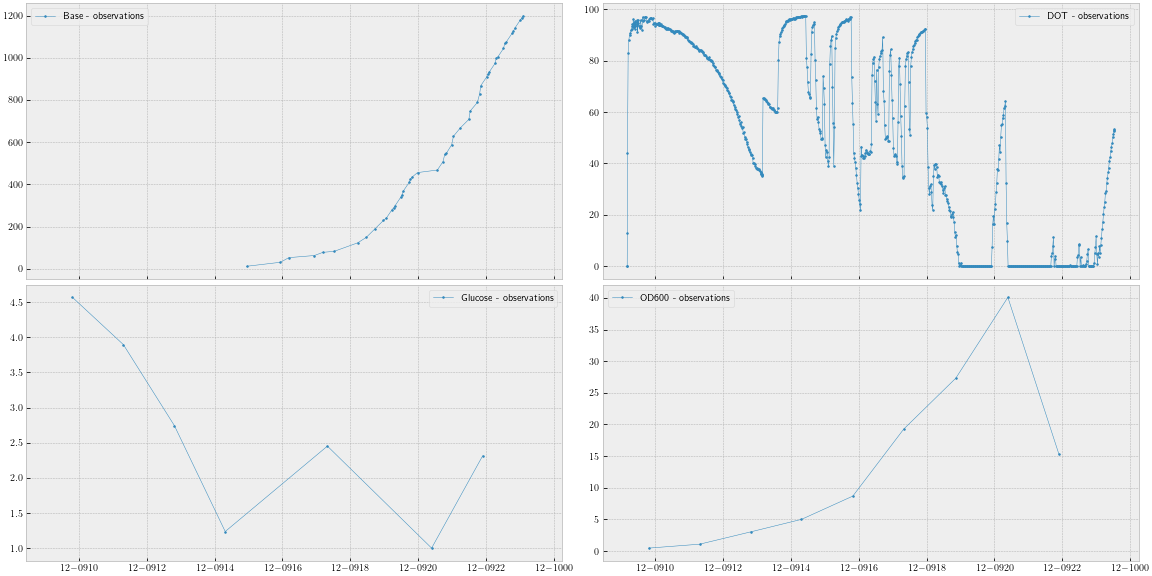

In [15]:
%matplotlib widget

fig, axes = plt.subplots(
    nrows=2, ncols=2, sharex=True, figsize=(16, 8), constrained_layout=True
)

for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
    data = ts[target]
    times = ts.index.values
    mask = ~np.isnan(data)
    ax.plot(
        times[mask],
        data[mask],
        ls="-",
        lw=0.5,
        marker=".",
        ms=3,
    )
    ax.legend([f"{target} - observations"])

In [16]:
batches = slices.iloc[[0, 300, 600, 900, 1200]]

for batch in batches:
    make_plot(axes, task, batch)

fig.savefig(f"{NAME.replace(r'/', r'_')}.pdf")

                     Flow_Air  StirringSpeed  Temperature   Acetate  \
measurement_time                                                      
2020-12-09 09:10:09 -0.716615    -126.718536    36.341717  0.137383   
2020-12-09 09:10:19  7.973160    1304.031372    36.732609  0.157226   
2020-12-09 09:10:24  7.978997    1392.827271    37.311626  0.167796   
2020-12-09 09:10:25  7.978990    1388.827271    38.571751  0.180380   
2020-12-09 09:10:34  7.978990    -485.000702    39.251766  0.187860   
...                       ...            ...          ...       ...   
2020-12-09 09:50:50  7.978998    1392.918945    38.639805  0.249596   
2020-12-09 09:50:59  7.978996    1390.502319    38.806599  0.249674   
2020-12-09 09:52:02  7.978998    1392.952515    38.570442  0.249595   
2020-12-09 09:52:11  7.978997    1390.840454    38.702980  0.249761   
2020-12-09 09:53:13  7.978999    1392.928345    38.577068  0.249598   

                           Base  Cumulated_feed_volume_glucose  \
measuremen

In [17]:
next(iter(TRAINLOADER))[0]

tensor([[0.1959, 0.1959, 0.1959,  ..., 0.1961, 0.1961, 0.1961],
        [0.4105, 0.4105, 0.4105,  ..., 0.4107, 0.4107, 0.4107],
        [0.7183, 0.7183, 0.7183,  ..., 0.7184, 0.7184, 0.7184],
        ...,
        [0.9983, 0.9983, 0.9983,  ..., 0.9984, 0.9984, 0.9984],
        [0.7183, 0.7183, 0.7183,  ..., 0.7184, 0.7184, 0.7184],
        [0.7183, 0.7183, 0.7183,  ..., 0.7184, 0.7184, 0.7184]],
       device='cuda:0')

In [18]:
from tsdm.encoders.modular import DateTimeEncoder, MinMaxScaler

In [19]:
enc = MinMaxScaler() @ DateTimeEncoder()
enc.fit(ts.index)
encoded = enc.encode(ts.index)

Float64Index([                   0.0, 0.00019336375589759454,
              0.00029004563384639183, 0.00030938200943615127,
              0.00048340938974398634,  0.0005800912676927837,
               0.0007541186480006187,  0.0008314641503596565,
                0.000850800525949416,  0.0010248279062572512,
              ...
                  0.9953979426096372,     0.9965967978962023,
                  0.9967708252765101,      0.998143707943383,
                  0.9993232268543584,      0.999516590610256,
                  0.9995552633614355,     0.9997292907417433,
                  0.9999419908732307,     0.9999999999999999],
             dtype='float64', name='measurement_time', length=1529)

In [20]:
np.array(data)

array([nan, nan, nan, ..., nan, nan, nan], dtype=float32)

In [21]:
DateTimeEncoder().fit(ts.index)